<a href="https://colab.research.google.com/github/gtsagkatakis/Data-Science-and-Applications-2026/blob/main/Multimodal_Universe_Getting_Started_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### Copyright 2024 Multimodal Universe Collaboration

Licensed under MIT License (the "License")

**Authors**:
- [@EiffL](https://github.com/EiffL) (Francois Lanusse)

# Getting Started with the Multimodal Universe Dataset!

<p align="center">
<img src="https://raw.githubusercontent.com/MultimodalUniverse/MultimodalUniverse/main/assets/multimodal_universe.png" alt="drawing" width="400"/>
<p>

### Overview

In this notebook we demonstrate how to access the data from the Multimodal Universe dataset, provide explanations about how to understand and work with each modality, and provide examples of multimodal cross-matching.

### Learning Objectives

In this notebook, we will learn how to:
 - Access datasets of different modalities
 - Cross-match different datasets


### Installs and Imports

To get started with the dataset, we only need to install Hugging Face Datasets:

### Overview

This notebook introduces the Multimodal Universe dataset, demonstrating how to:
- **Access datasets of different modalities**: It shows how to load image data (Legacy Survey), spectroscopic data (SDSS), and time-series data (plasticc) using the Hugging Face `datasets` library.
- **Understand and work with each modality**: Examples are provided to inspect the structure of the data for each modality.
- **Perform multimodal cross-matching**: It illustrates how to combine different datasets based on celestial coordinates to create a unified dataset containing multiple modalities for the same astronomical objects.

In [ ]:
# Installing Hugging Face datasets
!pip install datasets==3.6.0 --quiet

And that's it, we are set 😀 Let's just import a few things and then we can get started:

In [ ]:
%pylab inline
from datasets import load_dataset

Populating the interactive namespace from numpy and matplotlib


## Image Samples


### Image Samples

This section focuses on image data, specifically from the Legacy Survey (`MultimodalUniverse/legacysurvey`):
- **`load_dataset('MultimodalUniverse/legacysurvey', streaming=True, split='train')`**: Loads the Legacy Survey dataset in streaming mode, which is efficient for large datasets as it loads data on demand.
- **`.with_format('numpy')`**: Converts the dataset format to NumPy arrays, making it easy to work with numerical data.
- **`iter(dset_ls)` and `next(dset_iterator)`**: Creates an iterator to fetch individual examples from the streaming dataset.
- **`example.keys()`**: Shows the available keys/features within a single image example (e.g., `'image'`, `'rgb'`, `'catalog'`, `'object_id'`).
- **Plotting code**: Visualizes the different bands (filters) of an astronomical image using `matplotlib` to display the flux in each band.

In [ ]:
dset_ls = load_dataset("MultimodalUniverse/legacysurvey",
                       streaming=True,
                       split='train')
dset_ls = dset_ls.with_format("numpy")
dset_iterator = iter(dset_ls)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/165 [00:00<?, ?it/s]

In [ ]:
example = next(dset_iterator)

In [ ]:
# Let's inspect what is contained in an example
example.keys()

dict_keys(['image', 'blobmodel', 'rgb', 'object_mask', 'catalog', 'EBV', 'FLUX_G', 'FLUX_R', 'FLUX_I', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2', 'FLUX_W3', 'FLUX_W4', 'SHAPE_R', 'SHAPE_E1', 'SHAPE_E2', 'object_id'])

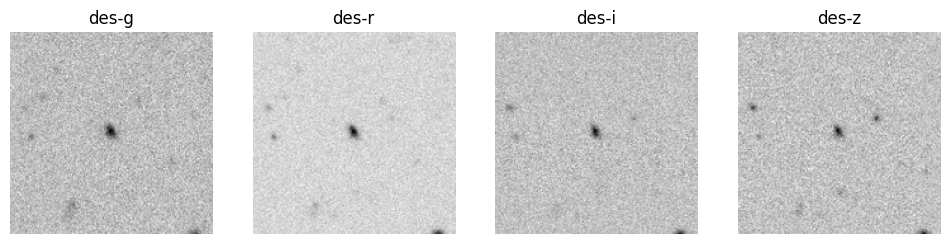

In [ ]:
figure(figsize=(12,5))
for i,b in enumerate(example['image']['band']):
  subplot(1,4,i+1)
  title(f'{b}')
  imshow(example['image']['flux'][i], cmap='gray_r')
  axis('off')

## Spectra Samples

### Spectra Samples

This part demonstrates handling spectroscopic data from the Sloan Digital Sky Survey (SDSS):
- **`load_dataset('MultimodalUniverse/sdss', streaming=True, split='train')`**: Loads the SDSS spectral dataset, similar to the image data.
- **`example.keys()`**: Inspects the keys for a spectral example, revealing features like `'spectrum'`, `'VDISP'`, `'Z'` (redshift), and various spectral flux measurements.
- **Plotting code**: Plots the spectrum, showing flux as a function of wavelength. The mask `m = example['spectrum']['lambda'] > 0` is used to remove padding values, which are indicated by `lambda` values less than or equal to zero.

In [ ]:
dset_sdss = load_dataset("MultimodalUniverse/sdss",
                       streaming=True,
                       split='train')
dset_sdss = dset_sdss.with_format("numpy")
dset_iterator = iter(dset_sdss)

README.md: 0.00B [00:00, ?B/s]

In [ ]:
example = next(dset_iterator)

In [ ]:
# Let's inspect what is contained in an example
example.keys()

dict_keys(['spectrum', 'VDISP', 'VDISP_ERR', 'Z', 'Z_ERR', 'ZWARNING', 'SPECTROFLUX_U', 'SPECTROFLUX_G', 'SPECTROFLUX_R', 'SPECTROFLUX_I', 'SPECTROFLUX_Z', 'SPECTROFLUX_IVAR_U', 'SPECTROFLUX_IVAR_G', 'SPECTROFLUX_IVAR_R', 'SPECTROFLUX_IVAR_I', 'SPECTROFLUX_IVAR_Z', 'SPECTROSYNFLUX_U', 'SPECTROSYNFLUX_G', 'SPECTROSYNFLUX_R', 'SPECTROSYNFLUX_I', 'SPECTROSYNFLUX_Z', 'SPECTROSYNFLUX_IVAR_U', 'SPECTROSYNFLUX_IVAR_G', 'SPECTROSYNFLUX_IVAR_R', 'SPECTROSYNFLUX_IVAR_I', 'SPECTROSYNFLUX_IVAR_Z', 'object_id'])

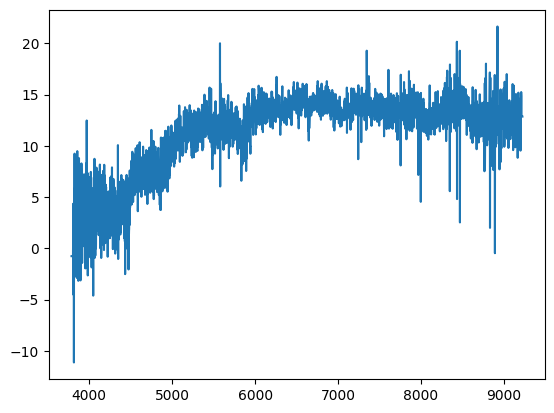

In [ ]:
# For plotting, we remove the padding values that are recognizable by the -1
m = example['spectrum']['lambda'] > 0

plot(example['spectrum']['lambda'][m],
     example['spectrum']['flux'][m])

## Time-Series sample

### Time-Series Sample

This section covers time-series data, specifically from the PLASTICC supernova dataset:
- **`load_dataset('MultimodalUniverse/plasticc', streaming=True, split='train')`**: Loads the PLASTICC dataset.
- **`example.keys()`**: Displays keys like `'lightcurve'`, `'hostgal_photoz'`, `'redshift'`, and `'obj_type'` for a time-series example.
- **Plotting code**: Visualizes the light curve, showing the object's flux changes over time in different observational bands. The `unique(example['lightcurve']['band'])` call identifies distinct bands, and the `m` mask filters for valid flux values.

In [ ]:
dset_plasticc = load_dataset("MultimodalUniverse/plasticc",
                       streaming=True,
                       split='train')
dset_plasticc = dset_plasticc.with_format("numpy")
dset_iterator = iter(dset_plasticc)

README.md: 0.00B [00:00, ?B/s]

In [ ]:
example = next(dset_iterator)

In [ ]:
example.keys()

dict_keys(['lightcurve', 'hostgal_photoz', 'hostgal_specz', 'redshift', 'obj_type', 'object_id'])

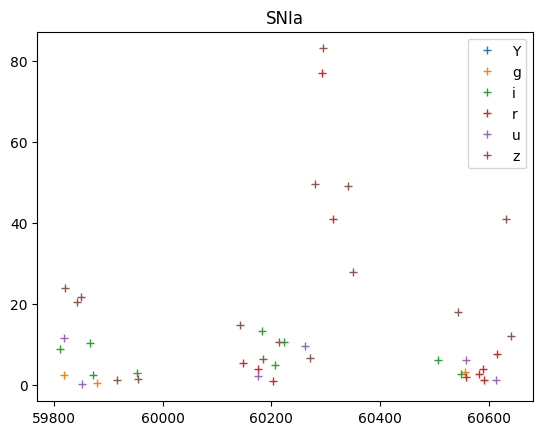

In [ ]:
for b in unique(example['lightcurve']['band']):
  m = (example['lightcurve']['flux'] > 0) & (example['lightcurve']['band'] == b)
  plot(example['lightcurve']['time'][m],
      example['lightcurve']['flux'][m],'+', label=b)
  title(example['obj_type'])
legend();

### Cross-Matching Across Modalities

This is a key part of the notebook, showing how to combine different astronomical datasets for the same objects:
- **`!pip install git+https://github.com/MultimodalUniverse/MultimodalUniverse.git --quiet`**: Installs the utility library from the Multimodal Universe project, which includes functions for cross-matching.
- **`!wget` commands**: Downloads a small, matching fraction of the HSC imaging sample and SDSS spectroscopic dataset to local storage for demonstration purposes.
- **Patching `sdss.py`**: A fix is applied to the `sdss.py` script to address a data type handling issue (`.newbyteorder` vs. `.view(...)`) that can arise with different NumPy versions or environments. This ensures proper data loading.
- **`from mmu.utils import cross_match_datasets`**: Imports the specific utility function for cross-matching.
- **`load_dataset_builder(...)`**: Loads the dataset builders for the local HSC and SDSS data. `trust_remote_code=True` is used as these are custom datasets.
- **`cross_match_datasets(sdss, hsc, matching_radius=1.0)`**: This function performs the core cross-matching. It finds objects that appear in both the SDSS (spectra) and HSC (images) datasets within a specified angular distance (`matching_radius`). The result is a new Hugging Face dataset (`dset`) containing features from both parent datasets for the matched objects.
- **`dset.num_rows`**: Shows the number of objects found in the cross-matched catalog.
- **`dset.with_format('jax')`**: Formats the resulting dataset for use with JAX, a high-performance numerical computing library.
- **`example = dset[3]` and plotting code**: Fetches an example from the cross-matched dataset and plots both its spectrum (smoothed with a Gaussian filter) and its images across different bands, demonstrating that a single object now has data from multiple modalities.

## Cross-Matching Across Modalities

While each parent sample is based on a single modality, users can easily create datasets across modalities by using the provided utilities.

This requires downloading the datasets to cross-match locally on local storage, and installing our utility library.


In the example below, we download a small fraction of 2 parent samples for demonstration purposes. For real applications, please see the project README to see how to download entire datasets.


#### - Installing the utility library

In [ ]:
!pip install git+https://github.com/MultimodalUniverse/MultimodalUniverse.git --quiet

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


#### - Downloading a small fraction of the data

The lines below download specifically a matching small healpix region of both the HSC imaging sample, and the SDSS spectroscospic dataset.

In [ ]:
# Downloading a small fraction of the data for demonstration purposes
!wget -r -np -nH --cut-dirs=1 -R "index.html*" -q https://users.flatironinstitute.org/~polymathic/data/MultimodalUniverse/v1/hsc/pdr3_dud_22.5/healpix=1175/
!wget -r -np -nH --cut-dirs=1 -R "index.html*" -q https://users.flatironinstitute.org/~polymathic/data/MultimodalUniverse/v1/hsc/hsc.py
!wget -r -np -nH --cut-dirs=1 -R "index.html*" -q https://users.flatironinstitute.org/~polymathic/data/MultimodalUniverse/v1/sdss/sdss/healpix=1175/

!wget https://raw.githubusercontent.com/MultimodalUniverse/MultimodalUniverse/refs/heads/main/scripts/sdss/sdss.py -O data/MultimodalUniverse/v1/sdss/sdss.py

--2026-03-05 08:01:14--  https://raw.githubusercontent.com/MultimodalUniverse/MultimodalUniverse/refs/heads/main/scripts/sdss/sdss.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20516 (20K) [text/plain]
Saving to: ‘data/MultimodalUniverse/v1/sdss/sdss.py’

data/MultimodalUniv 100%[===================>]  20.04K  --.-KB/s    in 0s      

2026-03-05 08:01:15 (170 MB/s) - ‘data/MultimodalUniverse/v1/sdss/sdss.py’ saved [20516/20516]



In [ ]:
#!wget -r -np -nH --cut-dirs=1 -R "index.html*" -q https://users.flatironinstitute.org/~polymathic/data/MultimodalUniverse/v1/sdss/sdss.py

#### - Building cross-matched dataset

In [ ]:
from datasets import load_dataset_builder
from mmu.utils import cross_match_datasets

In [ ]:
# Load the dataset descriptions from local copy of the data
sdss = load_dataset_builder("data/MultimodalUniverse/v1/sdss", trust_remote_code=True)
hsc = load_dataset_builder("data/MultimodalUniverse/v1/hsc", trust_remote_code=True)

In [ ]:
import os

# Path to the sdss.py file
sdss_py_path = "data/MultimodalUniverse/v1/sdss/sdss.py"

# Read the content of the file
with open(sdss_py_path, 'r') as f:
    content = f.read()

# Define the first problematic line and its replacement
old_line_1_pattern = '            example[f] = data[f][i].astype("float32").newbyteorder(\'=\')'
new_line_1_replacement = '            example[f] = data[f][i].astype("float32").view(data[f][i].astype("float32").dtype.newbyteorder(\'=\'))'

# Define the second problematic line and its replacement (from the current traceback)
old_line_2_pattern = '                            example[f"{f}_{b}"] = data[f"{f}"][i][n].astype("float32").newbyteorder(\'=\')'
new_line_2_replacement = '                            example[f"{f}_{b}"] = data[f"{f}"][i][n].astype("float32").view(data[f"{f}"][i][n].astype("float32").dtype.newbyteorder(\'=\'))'

# Apply the first replacement
if old_line_1_pattern in content:
    content = content.replace(old_line_1_pattern, new_line_1_replacement)
    print(f"Fixed {sdss_py_path}: Replaced first problematic line.")
else:
    print(f"Warning: Did not find the first problematic line in {sdss_py_path}. The fix might not be applied.")

# Apply the second replacement
if old_line_2_pattern in content:
    content = content.replace(old_line_2_pattern, new_line_2_replacement)
    print(f"Fixed {sdss_py_path}: Replaced second problematic line.")
else:
    print(f"Warning: Did not find the second problematic line in {sdss_py_path}. The fix might not be applied.")

# Write the modified content back to the file
with open(sdss_py_path, 'w') as f:
    f.write(content)

print(f"Patched {sdss_py_path} successfully.")

# Original code from the cell, re-executing necessary imports for safety
from datasets import load_dataset_builder
from mmu.utils import cross_match_datasets

# Load the dataset descriptions from local copy of the data.
# Reloading to ensure the patched sdss.py is used.
sdss = load_dataset_builder("data/MultimodalUniverse/v1/sdss", trust_remote_code=True)
hsc = load_dataset_builder("data/MultimodalUniverse/v1/hsc", trust_remote_code=True)

# Use the cross matching utility to return a new HF dataset, the intersection
# of the parent samples.
dset = cross_match_datasets(sdss, # Left dataset
                            hsc,  # Right dataset
                            matching_radius=1.0, # Distance in arcsec
                            )

print("Initial number of matches: ", dset.num_rows) # Print the number of rows for confirmation

Fixed data/MultimodalUniverse/v1/sdss/sdss.py: Replaced first problematic line.
Fixed data/MultimodalUniverse/v1/sdss/sdss.py: Replaced second problematic line.
Patched data/MultimodalUniverse/v1/sdss/sdss.py successfully.
Initial number of matches:  25
Number of matches lost at healpix region borders:  0
Final size of cross-matched catalog:  25


Generating train split: 0 examples [00:00, ? examples/s]

Initial number of matches:  25


### Removing `metadata.widgets` for GitHub Compatibility

In [1]:
import nbformat
import os

# --- IMPORTANT: Replace 'your_notebook_name.ipynb' with the actual name of your notebook file ---
# You can find your notebook's name in the browser tab or by running `!ls` in a cell.
notebook_filename = "your_notebook_name.ipynb"
output_filename = "cleaned_notebook.ipynb"

if not os.path.exists(notebook_filename):
    print(f"Error: Notebook file '{notebook_filename}' not found. Please ensure the filename is correct.")
else:
    with open(notebook_filename, 'r', encoding='utf-8') as f:
        notebook_content = nbformat.read(f, as_version=4)

    if 'widgets' in notebook_content['metadata']:
        del notebook_content['metadata']['widgets']
        print(f"'metadata.widgets' removed from {notebook_filename}")
    else:
        print(f"'metadata.widgets' not found in {notebook_filename}. No changes made.")

    with open(output_filename, 'w', encoding='utf-8') as f:
        nbformat.write(notebook_content, f)

    print(f"Cleaned notebook saved as '{output_filename}'. You can now download this file and upload it to GitHub.")


Error: Notebook file 'your_notebook_name.ipynb' not found. Please ensure the filename is correct.


In [ ]:
# The resulting dataset contains columns from both parent samples
dset

Dataset({
    features: ['spectrum', 'VDISP', 'VDISP_ERR', 'Z', 'Z_ERR', 'ZWARNING', 'SPECTROFLUX_U', 'SPECTROFLUX_G', 'SPECTROFLUX_R', 'SPECTROFLUX_I', 'SPECTROFLUX_Z', 'SPECTROFLUX_IVAR_U', 'SPECTROFLUX_IVAR_G', 'SPECTROFLUX_IVAR_R', 'SPECTROFLUX_IVAR_I', 'SPECTROFLUX_IVAR_Z', 'SPECTROSYNFLUX_U', 'SPECTROSYNFLUX_G', 'SPECTROSYNFLUX_R', 'SPECTROSYNFLUX_I', 'SPECTROSYNFLUX_Z', 'SPECTROSYNFLUX_IVAR_U', 'SPECTROSYNFLUX_IVAR_G', 'SPECTROSYNFLUX_IVAR_R', 'SPECTROSYNFLUX_IVAR_I', 'SPECTROSYNFLUX_IVAR_Z', 'object_id', 'image', 'a_g', 'a_r', 'a_i', 'a_z', 'a_y', 'g_extendedness_value', 'r_extendedness_value', 'i_extendedness_value', 'z_extendedness_value', 'y_extendedness_value', 'g_cmodel_mag', 'g_cmodel_magerr', 'r_cmodel_mag', 'r_cmodel_magerr', 'i_cmodel_mag', 'i_cmodel_magerr', 'z_cmodel_mag', 'z_cmodel_magerr', 'y_cmodel_mag', 'y_cmodel_magerr', 'g_sdssshape_psf_shape11', 'g_sdssshape_psf_shape22', 'g_sdssshape_psf_shape12', 'r_sdssshape_psf_shape11', 'r_sdssshape_psf_shape22', 'r_sdsss

In [ ]:
# Formating HF Dataset to JAX
dset = dset.with_format('jax')

We now have a dataset that contains both images and spectra of the same object.

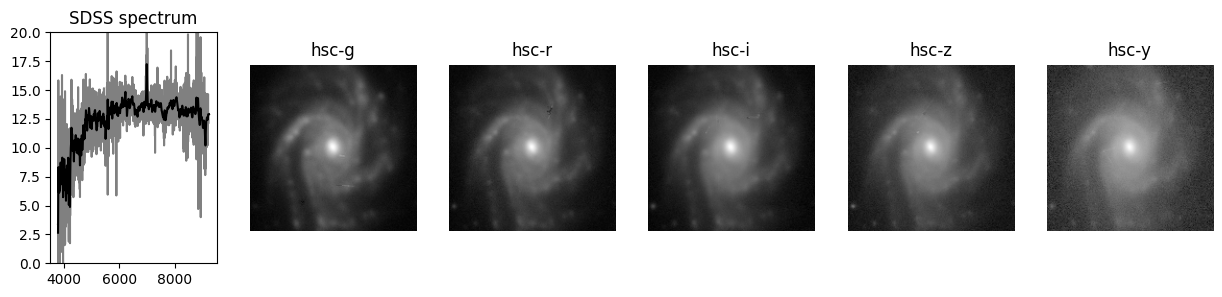

In [ ]:
example = dset[3]

from scipy.ndimage import gaussian_filter1d
figure(figsize=[15,3])
subplot(1,6,1)
ylim(0,20)
m = example['spectrum']['lambda'] > 0
plot(example['spectrum']['lambda'][m], example['spectrum']['flux'][m], color='gray')
plot(example['spectrum']['lambda'][m], gaussian_filter1d(example['spectrum']['flux'], sigma=5)[m], color='k')

title('SDSS spectrum')
for i in range (5):
    subplot(1,6,i+2)
    imshow(log10(example['image']['flux'][i] + 2.), cmap='gray')
    title(example['image']['band'][i])
    axis('off')